In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("synthetic_fraud_dataset.csv")

print("Original Data:")
print(df.head())

Original Data:
  Transaction_ID    User_ID  Transaction_Amount Transaction_Type  \
0      TXN_33553  USER_1834               39.79              POS   
1       TXN_9427  USER_7875                1.19    Bank Transfer   
2        TXN_199  USER_2734               28.96           Online   
3      TXN_12447  USER_2617              254.32   ATM Withdrawal   
4      TXN_39489  USER_2014               31.28              POS   

             Timestamp  Account_Balance Device_Type  Location  \
0  2023-08-14 19:30:00         93213.17      Laptop    Sydney   
1  2023-06-07 04:01:00         75725.25      Mobile  New York   
2  2023-06-20 15:25:00          1588.96      Tablet    Mumbai   
3  2023-12-07 00:31:00         76807.20      Tablet  New York   
4  2023-11-11 23:44:00         92354.66      Mobile    Mumbai   

  Merchant_Category  IP_Address_Flag  ...  Daily_Transaction_Count  \
0            Travel                0  ...                        7   
1          Clothing                0  ...    

In [3]:
df = df.fillna(df.mean(numeric_only=True))
df = df.select_dtypes(include=['float64', 'int64'])

In [4]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

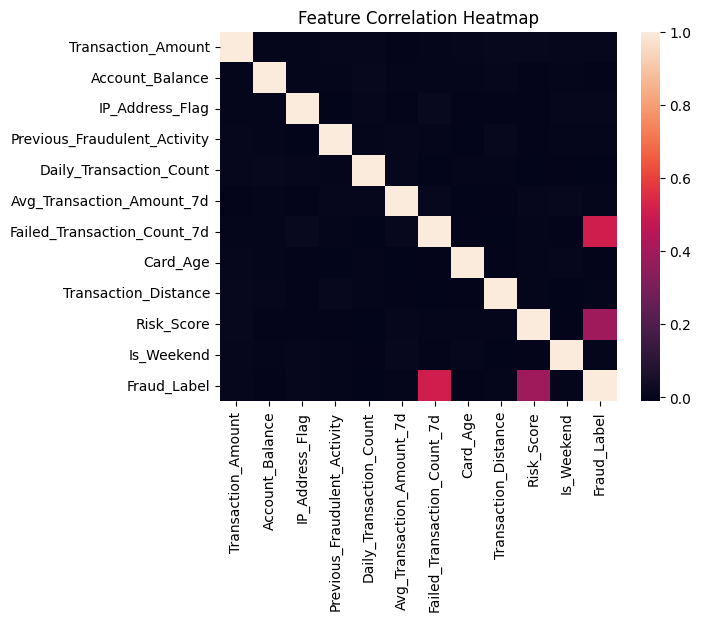

In [5]:
plt.figure()
sns.heatmap(df.corr(), annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

In [6]:
iso = IsolationForest(contamination=0.02, random_state=42)
df['Fraud'] = iso.fit_predict(scaled_data)
df['Fraud'] = df['Fraud'].map({1: 0, -1: 1})

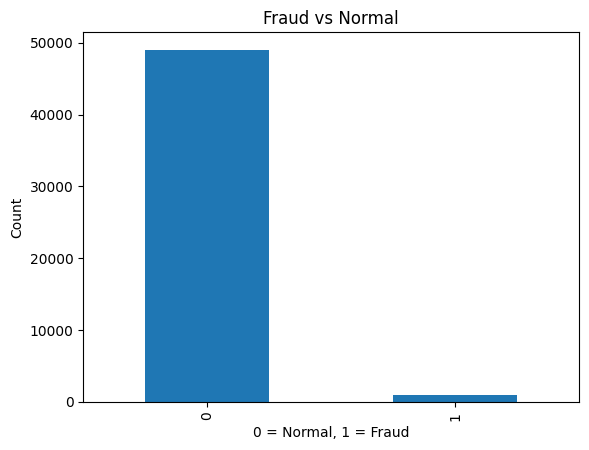

In [7]:
plt.figure()
df['Fraud'].value_counts().plot(kind='bar')
plt.title("Fraud vs Normal")
plt.xlabel("0 = Normal, 1 = Fraud")
plt.ylabel("Count")
plt.show()

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_data)

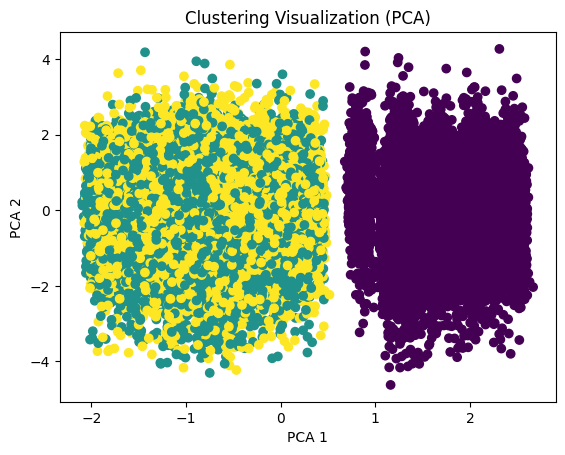

In [9]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.figure()
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=df['Cluster'])
plt.title("Clustering Visualization (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

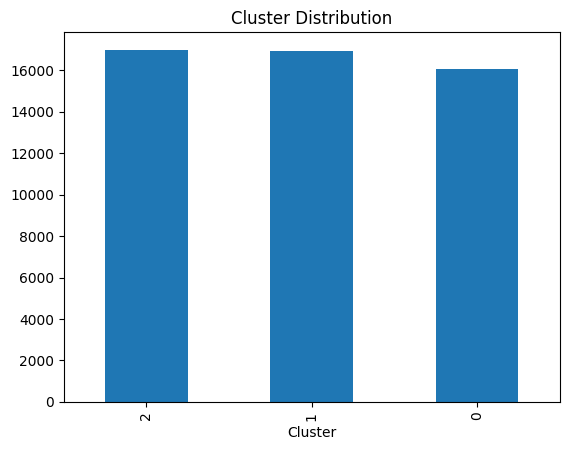

In [10]:
plt.figure()
df['Cluster'].value_counts().plot(kind='bar')
plt.title("Cluster Distribution")
plt.show()

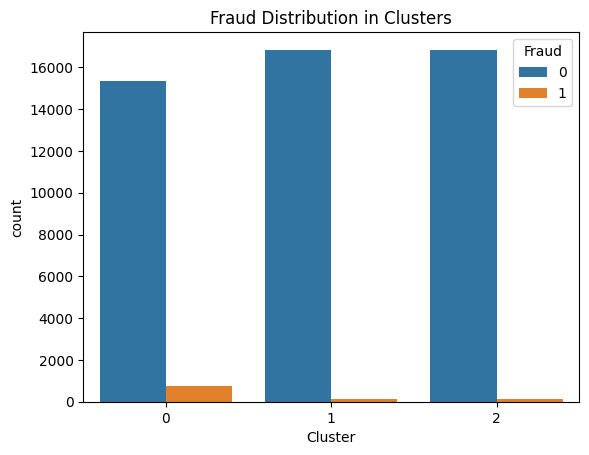

In [11]:
plt.figure()
sns.countplot(x='Cluster', hue='Fraud', data=df)
plt.title("Fraud Distribution in Clusters")
plt.show()

In [15]:
fraud_count = df['Fraud'].sum()

if fraud_count > 0:
    print("\nFraud Detected!")
else:
    print("\nNo Fraud Detected")

# Save output
df.to_csv("output.csv", index=False)


Fraud Detected!
